# Plotting and animation with PyVista grids

Simulation arrays contain values, but plotting also needs geometry and a mapping
from those values to mesh points or cells. Our PyVista objects keep that mapping
with the geometry, so the same grid can be passed to a PyVista plotter or a frame
renderer.

The custom mesh and element grids preserve original indices when extracting a
surface. Assigning `grid["voltage"] = values` can therefore map simulation data
onto the visible geometry without manually rebuilding the indexing for each
frame. Use `grid.point_data` or `grid.cell_data` for values already ordered by
the displayed grid's points or cells.

## Structured tissue mesh

`PyVistaMeshGrid.from_mesh()` converts a tissue array into cells, filters out
empty space, and optionally show only surface elements for faster rendering.
Here, x-coordinates of the occupied mesh cells provide a simple color field.


Mesh shape: (269, 279, 240)
Number of non-zero elements: 3845752
Coloring array shape: (3845752,)


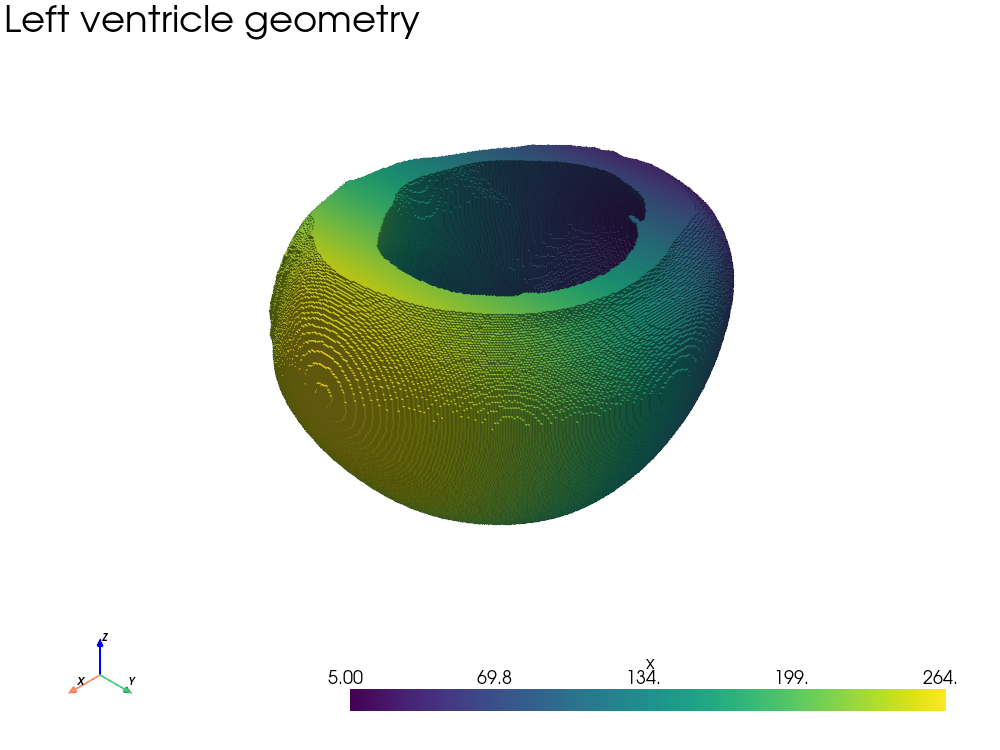

In [5]:
from pathlib import Path
import numpy as np
import pyvista as pv
import finitewave_tools.visualization as fwt


path = Path("./data")
mesh = np.load(path / "lv_mesh.npy")
x = np.argwhere(mesh > 0)[:, 0]

print(f"Mesh shape: {mesh.shape}")
print(f"Number of non-zero elements: {np.count_nonzero(mesh)}")
print(f"Coloring array shape: {x.shape}")

grid = fwt.PyVistaMeshGrid.from_mesh(mesh, as_surface=True)
grid["x"] = np.argwhere(mesh > 0)[:, 0]

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(1000, 750))
pl.set_background("white")
pl.add_text("Left ventricle geometry", font_size=16, color="black")
pl.add_mesh(grid, scalars="x", opacity=1.)
pl.show_axes()
pl.show()

## Surface mesh

`PyVistaSurfaceGrid` builds a surface from node coordinates and face connectivity.
It is useful when the input is surface, as in the atrial mesh
below. The resulting object can be plotted directly with PyVista.


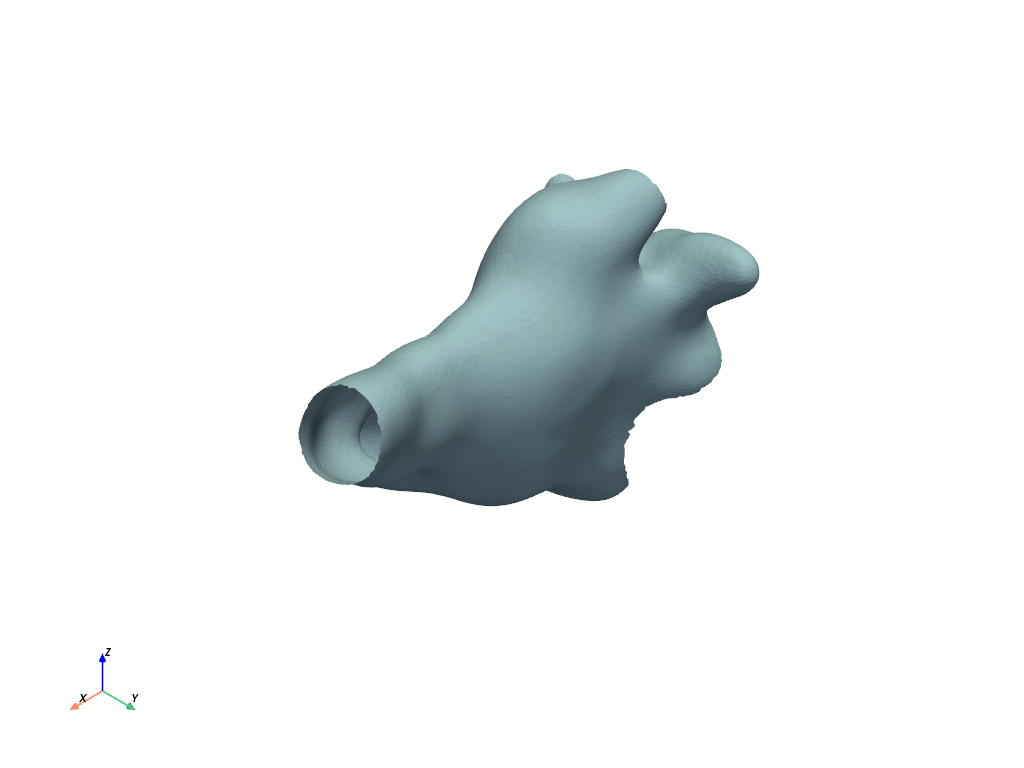

In [20]:
from pathlib import Path
import numpy as np
import pyvista as pv

import finitewave_tools.visualization as fwt

path = Path("./data")

points = np.load(path / "atrial_points.npy")
elems = np.load(path / "atrial_elems.npy")

pv.set_jupyter_backend("static")
surface = fwt.PyVistaSurfaceGrid(points, elems)
surface.plot(color="lightblue")

## Element mesh

`PyVistaElemGrid.from_elements()` builds a grid from coordinates, connectivity,
and an explicit element type. With `as_surface=True`, it retains the mapping from
boundary faces and points to the original volume mesh. This example assigns the
original nodes' x-coordinates to color the ventricular surface.


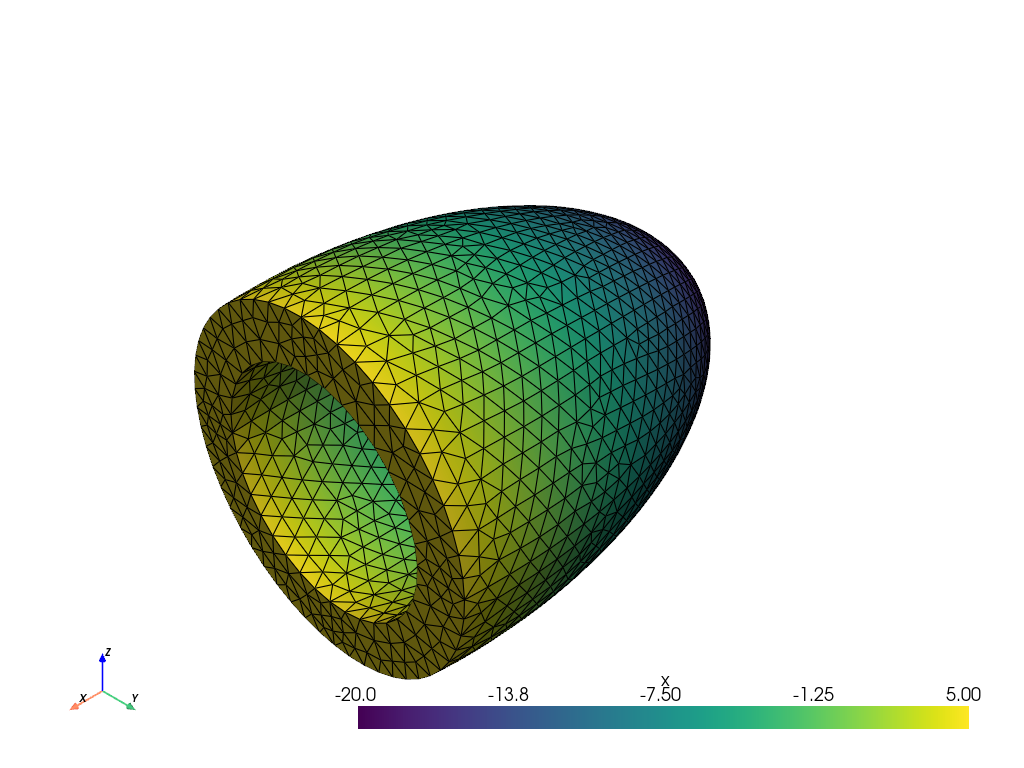

In [ ]:
from pathlib import Path
import numpy as np

import finitewave_tools.visualization as fwt

path = Path("./data")
lv_points = np.load(path / "lv_points.npy")
lv_elems = np.load(path / "lv_elems.npy")

pv.set_jupyter_backend("static")
lv_tetra = fwt.PyVistaElemGrid.from_elements(lv_points, lv_elems, cell_type="tetra", as_surface=True)
lv_tetra["x"] = lv_points[:, 0]
lv_tetra.plot(show_edges=True, scalars="x", cmap="viridis")

# 3D animation: wrapping x-coordinate colors

This example uses the left-ventricle tetrahedral mesh from `data/`. The geometry
stays fixed while color values shift along its x-axis. `wrap_x_coords` wraps
periodically into `[x_min, x_max)` instead of clipping at the endpoints.

Element-center x-coordinates are normalized to `[0, 1]`. We generate one scalar
per original tetrahedron; the grid maps each value to its boundary faces. The
cyclic `twilight` colormap uses fixed color limits.
The 72 frames cover one complete cycle at 24 frames per second (three seconds),
without duplicating the final frame.

MP4 export requires PyAV (`%pip install av`). Rendering runs off-screen; only the exported video is displayed.

The grid handles geometry and scalar assignment. `Frame3DRenderer` updates the
colors and captures RGB frames, while `AnimationBuilder` encodes those frames
into a video. This lets plotting and animation share the same mesh conversion.

Rendering method allows using callback function to apply changes during frame rendering,
such as switching camera position etc.


In [6]:
from pathlib import Path

import numpy as np
import finitewave_tools.visualization as fwv
import finitewave_tools.animation as fwa


def wrap_x_coords(x0, step, x_min, x_max):
    """Shift coordinates and wrap periodically into [x_min, x_max)."""
    if x_max <= x_min:
        raise ValueError("x_max must be greater than x_min.")
    return (np.asarray(x0) + step - x_min) % (x_max - x_min) + x_min


def switch_camera_position(renderer, frame_index):
    """Switch camera position between 'iso' and 'xy' every 10 frames."""
    if frame_index == 0:
        renderer.plotter.camera_position = "iso"
    if frame_index == 35:
        renderer.plotter.camera_position = "xy"


path = Path("./data")
lv_points = np.load(path / "lv_points.npy")
lv_elems = np.load(path / "lv_elems.npy")

elem_x = np.mean(lv_points[lv_elems], axis=1)[:, 0]

x_normalized = ((elem_x - elem_x.min()) / np.ptp(elem_x)).astype(np.float32)

fps = 24
n_frames = 72
frames = [
    wrap_x_coords(x_normalized, step, 0.0, 1.0)
    for step in np.linspace(0.0, 1.0, n_frames, endpoint=False)
]

animation_grid = fwv.PyVistaElemGrid.from_elements(
    lv_points, lv_elems, cell_type="tetra", as_surface=True
)
scalar_name = "Wrapped x"
animation_grid[scalar_name] = frames[0]

renderer = fwa.Frame3DRenderer()
renderer.set_frames(frames=frames)
renderer.configure_grid(
    animation_grid,
    window_size=(800, 800),
)

output_dir = Path("./output")
output_dir.mkdir(parents=True, exist_ok=True)

animation = fwa.AnimationBuilder()
animation.frame_renderer = renderer
animation.write(
    path=output_dir,
    animation_name="lv_wrapped_x",
    fps=fps,
    prog_bar=True,
    scalar_name=scalar_name,
    cmap="twilight",
    clim=(0.0, 1.0),
    callback=switch_camera_position
)

video_path = output_dir / "lv_wrapped_x.mp4"


Building animation: 100%|██████████| 72/72 [00:00<00:00, 130.64it/s]


## Display recorded animation

In [4]:
from IPython.display import Video, display

display(Video(str(video_path), embed=True, html_attributes="controls loop"))
